Feature Importance  - Face mask wearing

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib



Processing Australian Capital Territory
Feature Importance                                               Feature  Importance
8                                 7days_rolling_cases    0.120167
6                    protective_behavior_nomask_scale    0.061082
30           Pleasure in doing things_consent_removed    0.060068
7                                                week    0.052725
47      How Government handle situation_Somewhat well    0.051895
31            Feeling down/depressed_Nearly every day    0.039616
27                Pleasure in doing things_Not at all    0.027908
22  Confidence in Goverment's response_A lot of co...    0.027491
11                              Isolate if unwell_Yes    0.027437
3                                           Wellbeing    0.027098
37                 Feeling nervous/anxious_Not at all    0.025200
39               Feeling nervous/anxious_Several days    0.023522
36           Feeling nervous/anxious_Nearly every day    0.023324
1               

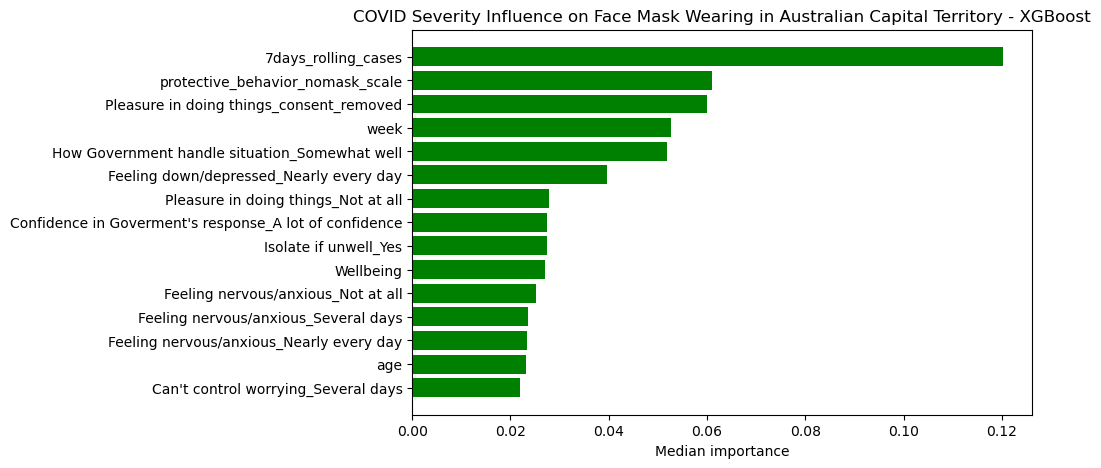


Processing New South Wales
Feature Importance                                               Feature  Importance
7                                                week    0.190018
6                    protective_behavior_nomask_scale    0.089318
16                 Isolate if instructed_Very willing    0.036767
4                                  Perceived Severity    0.026013
30           Pleasure in doing things_consent_removed    0.022161
5                            Perceived Susceptibility    0.021884
51                                  comorbidities_Yes    0.020955
3                                           Wellbeing    0.020013
8                                 7days_rolling_cases    0.019130
1                                                 age    0.017524
52                      comorbidities_consent_removed    0.017114
24  Confidence in Goverment's response_No confiden...    0.016923
40            Feeling nervous/anxious_consent_removed    0.016661
18                      emplo

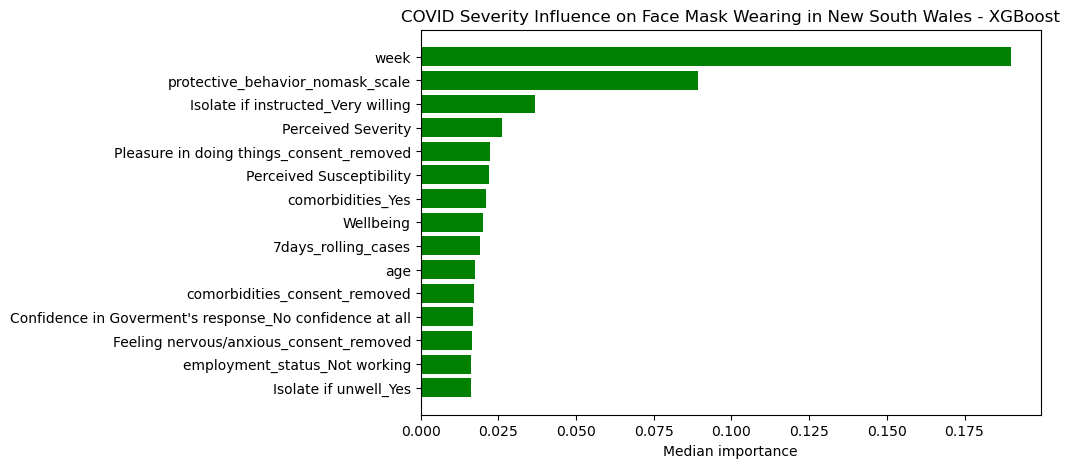


Processing Northern Territory
Feature Importance                                           Feature  Importance
7                                            week    0.164639
6                protective_behavior_nomask_scale    0.087066
48     How Government handle situation_Very badly    0.056052
8                             7days_rolling_cases    0.055574
26      Pleasure in doing things_Nearly every day    0.054307
47  How Government handle situation_Somewhat well    0.051331
11                          Isolate if unwell_Yes    0.047218
1                                             age    0.041318
3                                       Wellbeing    0.035227
5                        Perceived Susceptibility    0.035211
27            Pleasure in doing things_Not at all    0.035120
19         employment_status_Part time employment    0.034031
4                              Perceived Severity    0.032906
39           Feeling nervous/anxious_Several days    0.031037
34            Feelin

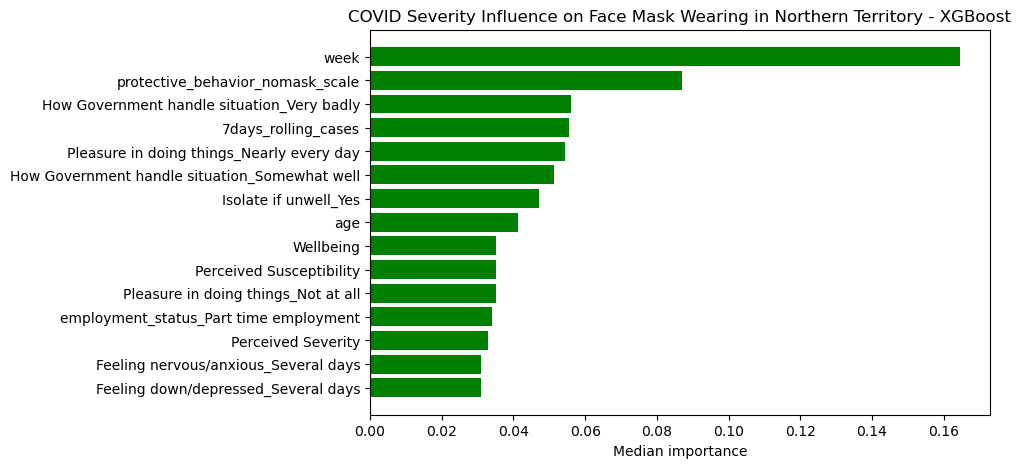


Processing Queensland
Feature Importance                                      Feature  Importance
7                                       week    0.140661
6           protective_behavior_nomask_scale    0.084260
9                       7days_rolling_deaths    0.040180
35    Feeling down/depressed_consent_removed    0.025832
8                        7days_rolling_cases    0.025392
4                         Perceived Severity    0.025314
10                Isolate if unwell_Not sure    0.022654
1                                        age    0.020936
15      Isolate if instructed_Very unwilling    0.020681
5                   Perceived Susceptibility    0.019981
3                                  Wellbeing    0.018622
14    Isolate if instructed_Somewhat willing    0.018077
2                             household_size    0.018030
36  Feeling nervous/anxious_Nearly every day    0.017368
52             comorbidities_consent_removed    0.017178


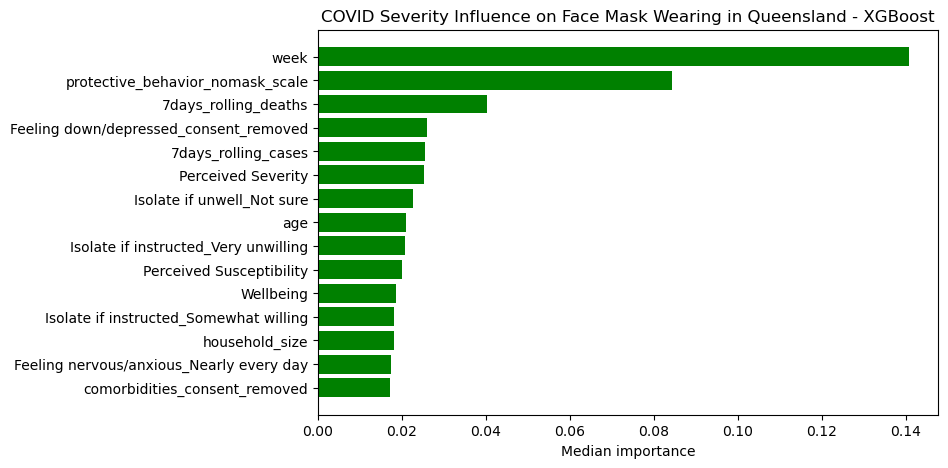


Processing South Australia
Feature Importance                                               Feature  Importance
7                                                week    0.205762
6                    protective_behavior_nomask_scale    0.055458
22  Confidence in Goverment's response_A lot of co...    0.040037
5                            Perceived Susceptibility    0.031896
52                      comorbidities_consent_removed    0.029701
16                 Isolate if instructed_Very willing    0.029003
15               Isolate if instructed_Very unwilling    0.026540
14             Isolate if instructed_Somewhat willing    0.025930
1                                                 age    0.020679
21                       employment_status_Unemployed    0.019916
24  Confidence in Goverment's response_No confiden...    0.019381
30           Pleasure in doing things_consent_removed    0.018786
19             employment_status_Part time employment    0.018124
4                            

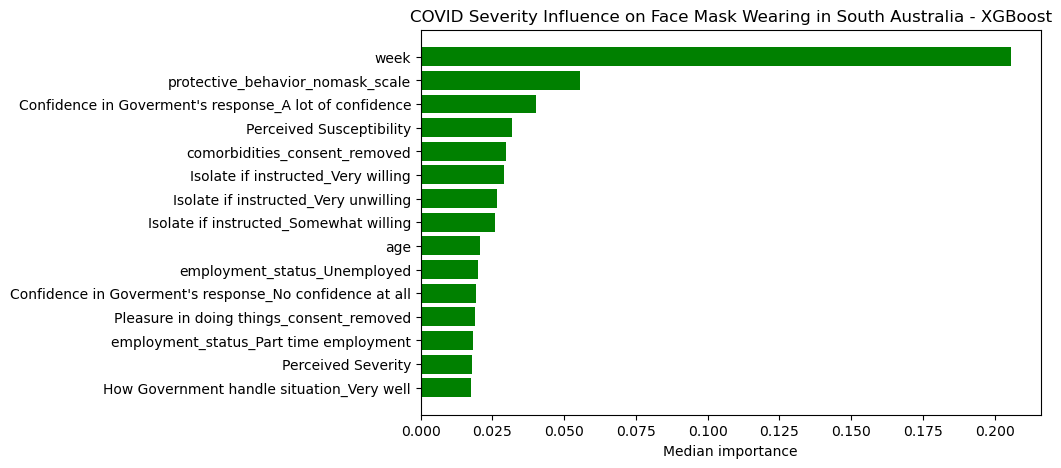


Processing Tasmania
Feature Importance                                               Feature  Importance
7                                                week    0.138310
6                    protective_behavior_nomask_scale    0.066748
21                       employment_status_Unemployed    0.052321
32                  Feeling down/depressed_Not at all    0.042456
29              Pleasure in doing things_Several days    0.040424
36           Feeling nervous/anxious_Nearly every day    0.036875
25  Confidence in Goverment's response_Not very mu...    0.035099
20                          employment_status_Retired    0.032294
19             employment_status_Part time employment    0.028753
5                            Perceived Susceptibility    0.028170
3                                           Wellbeing    0.027178
8                                 7days_rolling_cases    0.026534
31            Feeling down/depressed_Nearly every day    0.025344
14             Isolate if instructed

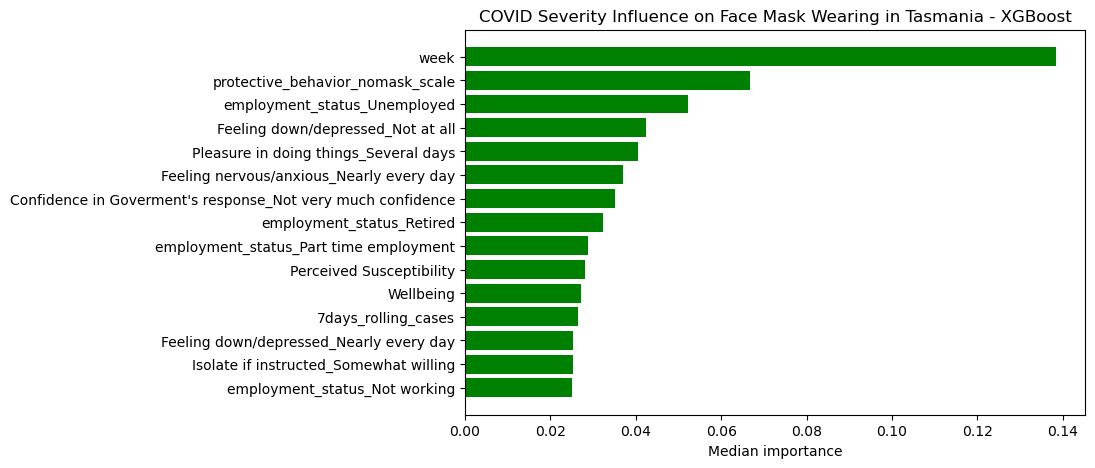


Processing Victoria
Feature Importance                                               Feature  Importance
6                    protective_behavior_nomask_scale    0.116157
7                                                week    0.106914
16                 Isolate if instructed_Very willing    0.048365
24  Confidence in Goverment's response_No confiden...    0.026913
11                              Isolate if unwell_Yes    0.025931
48         How Government handle situation_Very badly    0.024379
20                          employment_status_Retired    0.023475
10                         Isolate if unwell_Not sure    0.023060
25  Confidence in Goverment's response_Not very mu...    0.022841
4                                  Perceived Severity    0.022731
46     How Government handle situation_Somewhat badly    0.022703
1                                                 age    0.021349
3                                           Wellbeing    0.019498
8                                 7d

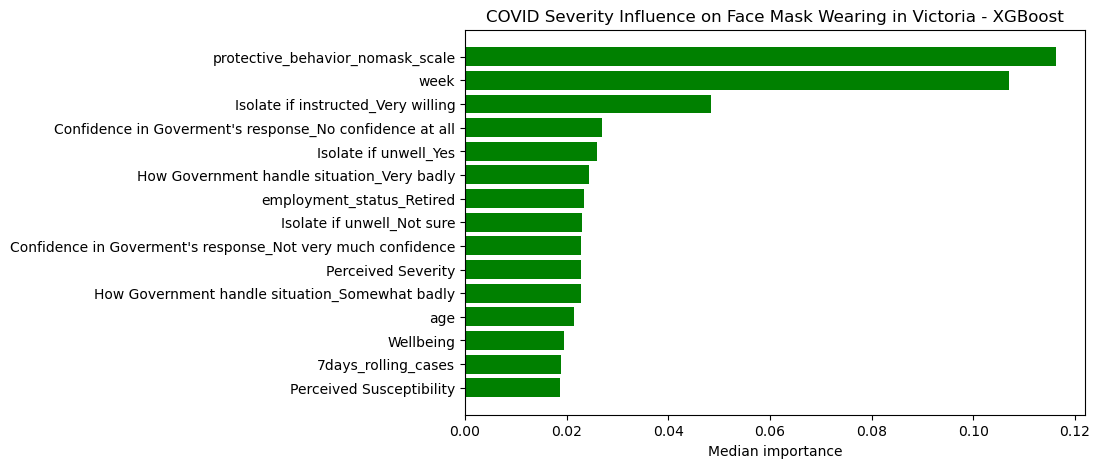


Processing Western Australia
Feature Importance                                               Feature  Importance
6                    protective_behavior_nomask_scale    0.179529
7                                                week    0.085627
22  Confidence in Goverment's response_A lot of co...    0.041405
52                      comorbidities_consent_removed    0.031086
49          How Government handle situation_Very well    0.030499
1                                                 age    0.029906
8                                 7days_rolling_cases    0.029635
5                            Perceived Susceptibility    0.029086
2                                      household_size    0.027289
4                                  Perceived Severity    0.023979
42                  Can't control worrying_Not at all    0.020818
0                              Non-household contacts    0.020687
25  Confidence in Goverment's response_Not very mu...    0.020609
3                          

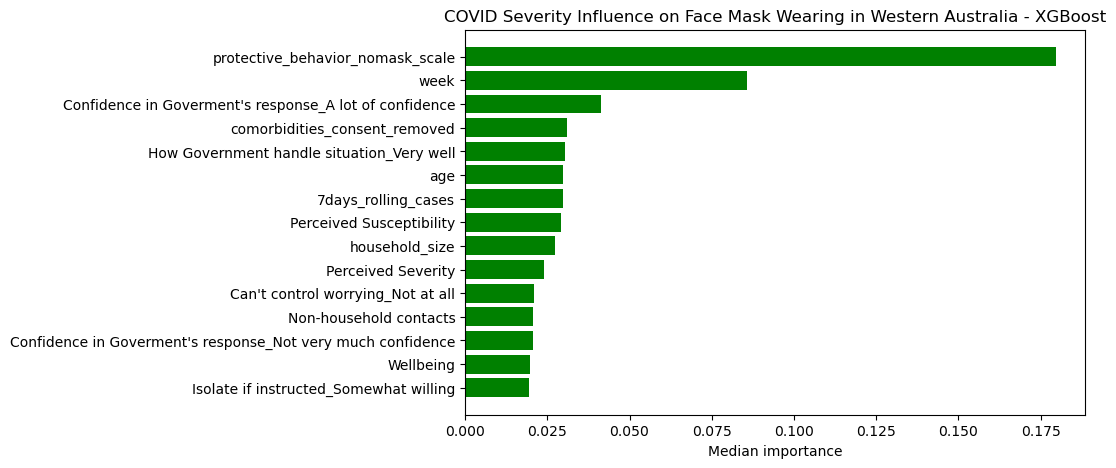

In [2]:
# face mask train set

state_train_facemask = pd.read_csv("state_train_facemask.csv")

states = sorted(state_train_facemask["state"].unique()) # to get 8 states

# remove the target variables and identifiers
drop_cols = ['RecordNo', 'Date', 'state', 'face_mask_scale', 'face_mask_binary','general_protective_behavior_scale',
                'general_protective_behavior_binary','mandate_start_date','mandate_period']







for state in states: # 8 XGBoost state models

    train_state = state_train_facemask[state_train_facemask["state"] == state]

    print(f"\nProcessing {state}")

    # predictors
    x_train = train_state.drop(columns=drop_cols)
    x_train = x_train.astype(float)  # converting boolean to float 


    # target variable
    y_train = train_state["face_mask_binary"]

    # best rf hyper parameters

    best_parameters = joblib.load(f"RQ2_facemask_{state}_XGBoost_bestParameters_rolling.pkl")






    # feature importance 


    # to keep all the importances in each run
    all_importances = []


    for i in range(100):
        
        temp_xgb = Pipeline([
        ('ros', RandomOverSampler(random_state=i)),
        ('xgb', XGBClassifier(random_state=i,
                              eval_metric='logloss',
                              n_jobs=-1))
        ])

        temp_xgb.set_params(**best_parameters)

        temp_xgb.fit(x_train, y_train)

        all_importances.append(temp_xgb.named_steps['xgb'].feature_importances_)





    all_importances = np.array(all_importances)

    # take the median / mean
    median_importance = np.median(all_importances, axis=0) # take the median of each column(feature) 


    feature_importance = pd.DataFrame({
        "Feature": x_train.columns,
        "Importance": median_importance
    })

    feature_importance = feature_importance.sort_values("Importance",ascending=False)

    top15 = feature_importance.head(15)

    print(f"Feature Importance",top15)
    feature_importance.to_csv(f"RQ2_facemask_{state}_XGBoost_FeatureImportance_rolling.csv",index=False)


    # plot
    plt.figure(figsize=(8,5))
    plt.barh(top15["Feature"], top15["Importance"], color="green")
    plt.title(f"COVID Severity Influence on Face Mask Wearing in {state} - XGBoost")
    plt.xlabel("Median importance")
    plt.gca().invert_yaxis()
    plt.savefig(f"RQ2_facemask_{state}_XGBoost_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")
    plt.show()
